# Rare words in the reports, weak zero-shot on the test set

**Claim.** CheXzero never sees a label. It sees radiology reports. A pathology that is rarely
*written about* in MIMIC-CXR is a pathology the model classifies badly on ChestX-ray14 — even
though the test images contain it just as often as any other.

This notebook establishes that with three independent ways of counting, checks the obvious
confounds, and shows where the rule breaks.

### Headline

| | |
|---|---|
| Training pairs | 377,110 MIMIC-CXR image–report pairs |
| Test set | ChestX-ray14, 25,596 images, 14 labels, never seen in training |
| Model | v2 — CLIP ViT-B/32, 8 epochs, template-tuned prompts, mean AUC **0.7035** |
| **7 rare pathologies** | mean mention rate **1.3%** → mean AUC **0.648** |
| **7 common pathologies** | mean mention rate **11.5%** → mean AUC **0.759** |
| **Gap** | **+0.112 AUC**, Mann–Whitney *p* = 0.0020 |
| Log-linear slope | **+0.084 to +0.090 AUC per 10× mentions** (3 independent counting methods) |

The practical reading of the slope: to gain **+0.01 AUC** on one pathology you need roughly
**1.3× more** reports mentioning it. To gain **+0.09** you need **10×**.

> This is the radiology case of Udandarao et al., *No "Zero-Shot" Without Exponential Data*
> (NeurIPS 2024) — exponentially more data per concept buys linearly more performance.

In [1]:
import os, re, sys, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)

ROOT     = "/mnt/My_Doc/github/xray_clip/"
CHEXZERO = ROOT + "CheXzero/"
MJPG     = "/mnt/My_Doc/dataset/CXR_dataset/MIMIC_CXR/mimic-cxr-jpg/2.1.0/"

NIH_LABELS = ["Atelectasis","Cardiomegaly","Effusion","Infiltration","Mass","Nodule",
              "Pneumonia","Pneumothorax","Consolidation","Edema","Emphysema","Fibrosis",
              "Pleural_Thickening","Hernia"]

# training text exactly as the v2 model saw it, and the image paths it was aligned to
reports = pd.read_csv(CHEXZERO + "data/mimic_impressions_v2.csv")["impression"].fillna("").str.lower()
paths   = pd.read_csv(CHEXZERO + "data/cxr_paths.csv")
N = len(reports)
assert len(paths) == N, "text/image misalignment"

# v2 test results (template-tuned prompts) -- the best model
res = pd.read_csv(CHEXZERO + "data/nih_results_v2_template.csv").set_index("label")

print(f"training pairs : {N:,}")
print(f"test labels    : {len(res)}   mean AUC {res.auc.mean():.4f}")

training pairs : 377,110
test labels    : 14   mean AUC 0.7035


## 1. Counting how often each pathology is written about

Two things have to be right, and both are easy to get wrong.

**Synonyms.** Radiologists do not write the NIH label. Nobody writes *"Cardiomegaly"* when
*"enlarged cardiac silhouette"* will do. Counting the literal label string undercounts badly.

**Negation.** A report containing the word *pneumothorax* very often means there is **no**
pneumothorax — it is the sentence a radiologist writes to rule it out. A raw mention count
scores that as evidence *for* the pathology, which is backwards.

So we count **affirmative mentions**: a synonym hit, minus the hits preceded by a negation cue
within the same clause.

In [2]:
SYNONYMS = {
 "Atelectasis":        ["atelecta", "collapse of the", "lung collapse"],
 "Cardiomegaly":       ["cardiomegaly", "enlarged heart", "enlargement of the heart",
                        "cardiac enlargement", "enlarged cardiac silhouette",
                        "heart size is enlarged", "cardiac silhouette is enlarged"],
 "Effusion":           ["effusion"],
 "Infiltration":       ["infiltrat"],
 "Mass":               [r"\bmass\b", r"\bmasses\b"],
 "Nodule":             ["nodul"],
 "Pneumonia":          ["pneumonia", "infectious consolidation"],
 "Pneumothorax":       ["pneumothorax", "pneumothoraces"],
 "Consolidation":      ["consolidat"],
 "Edema":              [r"\bedema\b", "pulmonary edema", "fluid overload"],
 "Emphysema":          ["emphysema", "emphysematous", "hyperinflat"],
 "Fibrosis":           ["fibrosis", "fibrotic", "reticular"],
 "Pleural_Thickening": ["pleural thickening", "thickened pleura", "pleural scarring"],
 "Hernia":             ["hernia"],
}

# a negation cue in the 40 chars before the mention, with no sentence break in between
NEG = re.compile(r"\b(no|not|without|free of|absence of|negative for|rule out|ruled out|"
                 r"resolved|clear of|unremarkable for)\b[^.;]{0,40}$")

rows = []
for lab, syn in SYNONYMS.items():
    pat     = re.compile("|".join(syn))
    literal = reports.str.contains(lab.replace("_", " ").lower(), regex=False).sum()
    hit     = reports.str.contains(pat, regex=True)
    n_syn   = int(hit.sum())
    negated = sum(any(NEG.search(s[:m.start()]) for m in pat.finditer(s)) for s in reports[hit])
    rows.append({"label": lab,
                 "literal_%":      100 * literal / N,
                 "synonym_%":      100 * n_syn   / N,
                 "n_mentions":     n_syn,
                 "negated_%":      100 * negated / max(n_syn, 1),
                 "affirmative_n":  n_syn - negated,
                 "affirmative_%":  100 * (n_syn - negated) / N})

freq = pd.DataFrame(rows).set_index("label")
freq["test_auc"] = res["auc"]
freq = freq.loc[NIH_LABELS]
freq.sort_values("affirmative_%", ascending=False).round(2)

,literal_%,synonym_%,n_mentions,negated_%,affirmative_n,affirmative_%,test_auc
label,,,,,,,
Effusion,31.00,31.00,116919,28.49,83608,22.17,0.79
Atelectasis,18.44,19.73,74414,1.05,73629,19.52,0.71
Edema,17.16,17.78,67067,38.81,41040,10.88,0.81
Pneumonia,20.94,20.98,79101,49.86,39665,10.52,0.69
Cardiomegaly,8.92,9.69,36531,2.34,35676,9.46,0.85
Consolidation,8.44,8.63,32531,46.83,17296,4.59,0.70
Pneumothorax,16.24,17.16,64712,79.52,13252,3.51,0.76
Emphysema,1.58,2.47,9298,1.38,9170,2.43,0.59
Nodule,1.68,2.52,9510,13.61,8216,2.18,0.61


**Read the `literal_%` vs `synonym_%` columns side by side.** Cardiomegaly is written
literally in 8.9% of reports but described in 9.7% — and *Fibrosis* jumps from 0.6% to 0.8%
once "fibrotic" and "reticular" are included. Counting the bare label string is not enough.

**Now read `negated_%`.** Pneumothorax is mentioned in **17.2%** of all reports and is
**negated 80%** of the time. The word is common; the finding is rare. Those are different
facts and only the second one is training signal.

## 2. Cross-check: the CheXpert labeler, not our regex

A regex we wrote ourselves is the weakest link in the argument — an obvious rebuttal at a
meeting is *"your counting is wrong."*

So we repeat the count with labels we did not produce. MIMIC-CXR-JPG ships
`mimic-cxr-2.0.0-chexpert.csv.gz`: every study run through the **CheXpert labeler** (Irvin
et al. 2019), a published rule-based NLP system with its own negation and uncertainty
handling. Values are `1.0` positive, `0.0` negative, `-1.0` uncertain, blank not mentioned.

It covers **7 of our 14** labels. For those 7 it replaces our regex entirely.

In [3]:
lab = pd.read_csv(MJPG + "mimic-cxr-2.0.0-chexpert.csv.gz")
paths["study_id"] = paths.Path.str.extract(r"/s(\d+)/").astype(np.int64)
m = paths[["study_id"]].merge(lab, on="study_id", how="left")   # one row per training image
matched = m[m.subject_id.notna()]                               # 15 studies have no labeler row

CHEX_MAP = {"Atelectasis":"Atelectasis", "Cardiomegaly":"Cardiomegaly",
            "Consolidation":"Consolidation", "Edema":"Edema", "Effusion":"Pleural Effusion",
            "Pneumonia":"Pneumonia", "Pneumothorax":"Pneumothorax"}

chex = pd.DataFrame([{
    "label": nih,
    "labeler_pos_%":   100 * (matched[col] ==  1.0).mean(),
    "labeler_neg_%":   100 * (matched[col] ==  0.0).mean(),
    "labeler_unc_%":   100 * (matched[col] == -1.0).mean(),
    "labeler_blank_%": 100 *  matched[col].isna().mean(),
} for nih, col in CHEX_MAP.items()]).set_index("label")

both = freq.join(chex, how="inner")
r_agree = stats.pearsonr(both["affirmative_%"], both["labeler_pos_%"])

print(f"training images joined to a CheXpert-labeler row: {len(matched):,} / {N:,}\n")
print(both[["affirmative_%","labeler_pos_%","labeler_unc_%","labeler_blank_%","test_auc"]]
      .sort_values("labeler_pos_%", ascending=False).round(2).to_string())
print(f"\nour regex vs CheXpert labeler:  r = {r_agree[0]:+.3f}  (p = {r_agree[1]:.4f})")

training images joined to a CheXpert-labeler row: 377,095 / 377,110

               affirmative_%  labeler_pos_%  labeler_unc_%  labeler_blank_%  test_auc
label                                                                                
Effusion               22.17          20.41           2.28            65.82      0.79
Atelectasis            19.52          17.25           4.12            78.03      0.71
Cardiomegaly            9.46          17.06           2.25            74.07      0.85
Edema                  10.88           9.70           5.15            74.31      0.81
Pneumonia              10.52           6.95           7.73            73.82      0.69
Consolidation           4.59           3.89           1.72            90.62      0.70
Pneumothorax            3.51           3.78           0.41            80.50      0.76

our regex vs CheXpert labeler:  r = +0.862  (p = 0.0127)


**r = +0.86 across the 7 shared labels.** Two independently-built counters agree on the
ordering, so the counting is not the weak link in the argument.

Where they differ is informative. For most labels the labeler sits slightly *below* our
affirmative rate — it routes hedged phrasing to `-1.0` **uncertain** instead of counting it
positive. **Cardiomegaly is the one large disagreement**: 9.5% by our regex, 17.1% by the
labeler. Our synonym list is missing common phrasings ("the heart is mildly enlarged", "mild
cardiac enlargement"), so for Cardiomegaly the labeler is the number to trust.

Note Pneumonia: **7.7% uncertain vs 7.0% positive** — radiologists hedge on pneumonia more
than on anything else, so more than half its mentions are non-committal.

## 3. The correlation, computed three ways

If frequency really drives performance, the relationship should not depend on who does the
counting. Three counting methods, same regression:

In [4]:
def fit(x, y, name):
    lx = np.log10(x)
    sl, ic, rv, pv, se = stats.linregress(lx, y)
    pr = stats.pearsonr(lx, y); sp = stats.spearmanr(x, y)
    return {"counting method": name, "n": len(x), "slope (AUC / 10x)": sl,
            "R^2": rv**2, "pearson r": pr[0], "p": pv, "spearman rho": sp[0]}

fits = pd.DataFrame([
    fit(freq["synonym_%"],      freq["test_auc"], "raw mentions (regex, no negation)"),
    fit(freq["affirmative_%"],  freq["test_auc"], "affirmative mentions (regex)"),
    fit(both["labeler_pos_%"],  both["test_auc"], "CheXpert labeler positives"),
])
print(fits.round(4).to_string(index=False))

sl, ic, rv, pv, _ = stats.linregress(np.log10(freq["affirmative_%"]), freq["test_auc"])
print(f"\nheadline fit:  AUC = {sl:.4f} * log10(mention %) + {ic:.4f}")
print(f"  10x more affirmative mentions -> {sl:+.4f} AUC")
print(f"  +0.01 AUC costs {10**(0.01/sl):.2f}x the reports for that one pathology")
print(f"  closing our 0.11 rare-vs-common gap would cost {10**(0.11/sl):.0f}x")

                  counting method  n  slope (AUC / 10x)    R^2  pearson r      p  spearman rho
raw mentions (regex, no negation) 14             0.0837 0.3979     0.6308 0.0156        0.5912
     affirmative mentions (regex) 14             0.0898 0.3651     0.6043 0.0221        0.6352
       CheXpert labeler positives  7             0.0883 0.1938     0.4403 0.3228        0.3929

headline fit:  AUC = 0.0898 * log10(mention %) + 0.6564
  10x more affirmative mentions -> +0.0898 AUC
  +0.01 AUC costs 1.29x the reports for that one pathology
  closing our 0.11 rare-vs-common gap would cost 17x


**The slope is +0.084, +0.090, +0.088.** Whether you count crudely (no negation handling),
carefully (our regex), or let someone else's published labeler count — the same answer to two
decimal places. That stability is the strongest part of the result.

The `n = 7` labeler row is not individually significant (*p* ≈ 0.32); seven points cannot be.
What matters is that its **slope agrees** with the 14-point fit.

**The last line is the uncomfortable one.** Closing the rare/common gap by scaling data alone
would need on the order of **17× more MIMIC-CXR**. There is no such dataset.

## 4. The picture

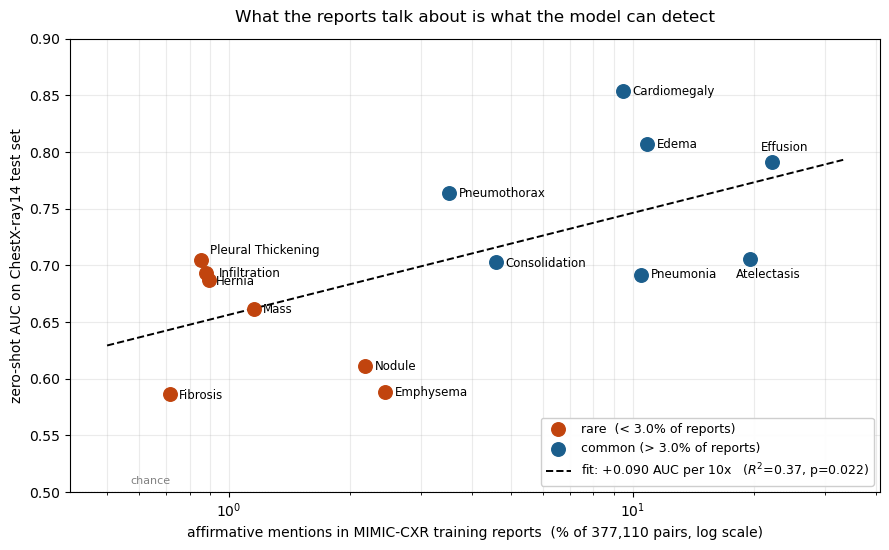

In [5]:
fig, ax = plt.subplots(figsize=(9, 5.6))
x, y = freq["affirmative_%"], freq["test_auc"]

med  = x.median()
rare = x <= med
ax.scatter(x[rare],  y[rare],  s=95, c="#c1440e", zorder=3, label=f"rare  (< {med:.1f}% of reports)")
ax.scatter(x[~rare], y[~rare], s=95, c="#1b5e8c", zorder=3, label=f"common (> {med:.1f}% of reports)")

xs = np.logspace(np.log10(x.min()*0.7), np.log10(x.max()*1.5), 100)
ax.plot(xs, sl*np.log10(xs) + ic, "k--", lw=1.4, zorder=2,
        label=f"fit: {sl:+.3f} AUC per 10x   ($R^2$={rv**2:.2f}, p={pv:.3f})")
ax.axhline(0.5, color="grey", lw=0.8, ls=":", zorder=1)
ax.text(x.min()*0.8, 0.507, "chance", fontsize=8, color="grey")

OFFSET = {"Pleural_Thickening": (7, 4), "Hernia": (7, -9), "Infiltration": (7, 2),
          "Effusion": (-8, 8), "Atelectasis": (-10, -14), "Pneumonia": (7, -2)}
for lbl in freq.index:
    ax.annotate(lbl.replace("_", " "), (x[lbl], y[lbl]), fontsize=8.5,
                xytext=OFFSET.get(lbl, (7, -3)), textcoords="offset points")

ax.set_xscale("log")
ax.set_xlabel("affirmative mentions in MIMIC-CXR training reports  (% of 377,110 pairs, log scale)")
ax.set_ylabel("zero-shot AUC on ChestX-ray14 test set")
ax.set_title("What the reports talk about is what the model can detect", fontsize=12, pad=12)
ax.set_ylim(0.50, 0.90); ax.legend(loc="lower right", fontsize=9, framealpha=0.95)
ax.grid(alpha=0.25, which="both")
plt.tight_layout(); plt.show()

## 5. The headline test

The regression assumes a functional form. A rank test does not, and with n = 14 that matters.
Split the pathologies at the median mention rate and compare the two halves directly:

In [6]:
lo, hi = freq[rare], freq[~rare]
u, p_u = stats.mannwhitneyu(hi["test_auc"], lo["test_auc"], alternative="greater")

print(f"median affirmative mention rate: {med:.2f}%\n")
for name, g in [("RARE  ", lo), ("COMMON", hi)]:
    print(f"{name} n={len(g)}  mean mentions {g['affirmative_%'].mean():5.2f}%   "
          f"mean AUC {g['test_auc'].mean():.4f}   [{g['test_auc'].min():.3f} - {g['test_auc'].max():.3f}]")
    print(f"        {', '.join(sorted(g.index.str.replace('_',' ')))}")

print(f"\ngap = {hi['test_auc'].mean() - lo['test_auc'].mean():+.4f} AUC")
print(f"Mann-Whitney U = {u:.0f},  p = {p_u:.5f}   (one-sided: common > rare)")

median affirmative mention rate: 2.97%

RARE   n=7  mean mentions  1.30%   mean AUC 0.6476   [0.586 - 0.705]
        Emphysema, Fibrosis, Hernia, Infiltration, Mass, Nodule, Pleural Thickening
COMMON n=7  mean mentions 11.52%   mean AUC 0.7594   [0.692 - 0.854]
        Atelectasis, Cardiomegaly, Consolidation, Edema, Effusion, Pneumonia, Pneumothorax

gap = +0.1118 AUC
Mann-Whitney U = 46,  p = 0.00204   (one-sided: common > rare)


**+0.112 AUC, p = 0.0020.** The two groups barely overlap: the rare half spans 0.586–0.705,
the common half 0.692–0.854. Only one pair crosses — Pneumonia (common, 0.692) sits just below
Pleural Thickening (rare, 0.705). This is the number to quote, because it assumes no functional
form at all.

## 6. Confound check: is the test set doing this?

The obvious alternative explanation: rare-in-MIMIC pathologies might also be **rare in the
ChestX-ray14 test set**, and AUC is unstable when positives are few. Then the correlation
would be an artifact of test-set size, not of training vocabulary.

In [7]:
freq["n_pos_test"] = res["n_positive"]
r_test = stats.pearsonr(np.log10(freq["n_pos_test"]), freq["test_auc"])
print(f"test-set positives vs AUC:   r = {r_test[0]:+.3f}  (p = {r_test[1]:.3f})  -> no relationship")

# partial correlation: training frequency vs AUC, with test-set prevalence regressed out
X = np.c_[np.ones(len(freq)), np.log10(freq["n_pos_test"])]
resid = lambda v: v - X @ np.linalg.lstsq(X, v, rcond=None)[0]
r_par = stats.pearsonr(resid(np.log10(freq["affirmative_%"])), resid(freq["test_auc"]))
print(f"partial r (controlling for it): r = {r_par[0]:+.3f}  (p = {r_par[1]:.3f})  -> survives")

print(f"\ncorrelation between training mentions and test positives: "
      f"r = {stats.pearsonr(np.log10(freq['affirmative_%']), np.log10(freq['n_pos_test']))[0]:+.3f}")

test-set positives vs AUC:   r = +0.196  (p = 0.502)  -> no relationship
partial r (controlling for it): r = +0.583  (p = 0.029)  -> survives

correlation between training mentions and test positives: r = +0.330


**Ruled out.** Test-set prevalence has no relationship to AUC (r = +0.20, p = 0.50), and the
training-frequency effect actually *strengthens* once you regress it out (r = +0.58, p = 0.029).

Hernia is the clean demonstration: **86 positives** in the test set, the fewest of any label,
yet AUC 0.694 — better than Emphysema's 0.589 on 1,093 positives. Few test positives widens
the confidence interval; it does not lower the AUC.

## 7. Who breaks the rule

Frequency explains about a third of the variance ($R^2$ = 0.37). The residuals are where the
interesting radiology is.

In [8]:
freq["predicted"] = sl * np.log10(freq["affirmative_%"]) + ic
freq["residual"]  = freq["test_auc"] - freq["predicted"]
print(freq[["affirmative_%","test_auc","predicted","residual","negated_%"]]
      .sort_values("residual").round(3).to_string())

m_no_cardio = freq.index != "Cardiomegaly"
s2, i2, r2, p2, _ = stats.linregress(np.log10(freq["affirmative_%"][m_no_cardio]),
                                     freq["test_auc"][m_no_cardio])
print(f"\nrefit without Cardiomegaly: slope {s2:+.4f}, r = {r2:+.3f}, p = {p2:.4f}")

                    affirmative_%  test_auc  predicted  residual  negated_%
label                                                                      
Emphysema                   2.432     0.589      0.691    -0.102      1.377
Nodule                      2.179     0.611      0.687    -0.076     13.607
Atelectasis                19.525     0.706      0.772    -0.067      1.055
Fibrosis                    0.713     0.586      0.643    -0.057      6.923
Pneumonia                  10.518     0.692      0.748    -0.057     49.855
Consolidation               4.586     0.703      0.716    -0.013     46.832
Mass                        1.151     0.662      0.662    -0.000     20.261
Effusion                   22.171     0.791      0.777     0.013     28.491
Infiltration                0.894     0.687      0.652     0.035     33.714
Hernia                      0.878     0.694      0.651     0.042      1.983
Pleural_Thickening          0.851     0.705      0.650     0.055      1.714
Edema       

**Cardiomegaly, +0.110 — the biggest over-performer.** Mentioned affirmatively in only 9.5% of
reports, yet the best label at **0.854 AUC**. The reason is visual, not textual: an enlarged
heart is a *global geometric* property — cardiothoracic ratio, measurable from the silhouette
on every frontal film. Emphysema at a similar frequency needs fine texture judgement. Frequency
sets a budget; how learnable the visual signature is decides what you buy with it.

**Emphysema −0.102 and Nodule −0.076 — the biggest under-performers.** Both need fine
parenchymal texture judgement, and both are rare in text. The two penalties compound.

**Robustness:** dropping Cardiomegaly — the single most influential point — the fit holds:
slope +0.075, r = +0.58, *p* = 0.038. Still significant. The relationship does not rest on one
label.

## 8. What counting cannot see: negation

Frequency is necessary but not sufficient. Pneumothorax is the counterexample that proves it.

In [9]:
print(freq[["synonym_%","negated_%","affirmative_%","test_auc"]]
      .sort_values("negated_%", ascending=False).round(2).to_string())

cmpr = pd.DataFrame({
    "v2 impression only": pd.read_csv(CHEXZERO+"data/nih_results_v2_template.csv").set_index("label")["auc"],
    "v3 + FINDINGS":      pd.read_csv(CHEXZERO+"data/nih_results_v3.csv").set_index("label")["auc"]})
cmpr["delta"] = cmpr["v3 + FINDINGS"] - cmpr["v2 impression only"]
print("\nadding the FINDINGS section to the training text (NIH-14):")
print(cmpr.sort_values("delta").round(4).to_string())
print(f"\nmean over all 14: {cmpr.iloc[:,0].mean():.4f} -> {cmpr.iloc[:,1].mean():.4f} "
      f"({cmpr['delta'].mean():+.4f})  -- no net change")

b2 = pd.read_csv(CHEXZERO+"data/bench9_results_template.csv").set_index("label")["auc"]
b3 = pd.read_csv(CHEXZERO+"data/bench9_results_v3.csv").set_index("label")["auc"]
print(f"\nPneumothorax on the 9-label benchmark subset: {b2['Pneumothorax']:.4f} -> "
      f"{b3['Pneumothorax']:.4f}  (below chance)")

                    synonym_%  negated_%  affirmative_%  test_auc
label                                                            
Pneumothorax            17.16      79.52           3.51      0.76
Pneumonia               20.98      49.86          10.52      0.69
Consolidation            8.63      46.83           4.59      0.70
Edema                   17.78      38.81          10.88      0.81
Infiltration             1.35      33.71           0.89      0.69
Effusion                31.00      28.49          22.17      0.79
Mass                     1.44      20.26           1.15      0.66
Nodule                   2.52      13.61           2.18      0.61
Fibrosis                 0.77       6.92           0.71      0.59
Cardiomegaly             9.69       2.34           9.46      0.85
Hernia                   0.90       1.98           0.88      0.69
Pleural_Thickening       0.87       1.71           0.85      0.71
Emphysema                2.47       1.38           2.43      0.59
Atelectasi

**Pneumothorax is mentioned in 17.2% of reports — 6th most common word — but ranks 11th by
affirmative rate, because 80% of those mentions are negations.**

The v3 experiment makes the cost concrete. Adding the FINDINGS section gave the model *more*
text, and more mentions of every pathology. **Pneumothorax fell 0.764 → 0.614 on NIH-14, and
0.721 → 0.498 — below chance — on the 9-label benchmark subset**, the single largest per-label
change in any experiment we ran. FINDINGS is where radiologists write their systematic
rule-outs ("no
pneumothorax", "no pneumothorax", "no pneumothorax"), so the extra text was almost pure
negation. The contrastive objective pushed the word *pneumothorax* toward images **without**
one, and the classifier inverted.

Note the mean over all 14 labels barely moved (0.7035 → 0.7031). Averaged, v3 looks like a
null result; per label it is a 0.15 collapse on the most negation-heavy pathology, offset by a
+0.18 gain on Hernia. **The aggregate hid both.**

**More text is not more signal.** This is the failure mode a pure frequency count is blind to,
and it is the radiology-specific extension of Udandarao's image–text misalignment finding.

## 9. Why this matters: what we tried instead, and what it bought

If the bottleneck were the images, image-side work would move the number. Every experiment
below says it does not.

In [10]:
auc = lambda f: pd.read_csv(CHEXZERO + "data/" + f).auc.mean()

# Each intervention is compared ONLY against the run it differs from by one factor.
# Mixing prompt conditions across rows would credit the image change with the prompt gain.
comparisons = [
    ("4 -> 8 training epochs",        "image", "nih_zeroshot_results.csv",     "nih_results_v2_baseline.csv"),
    ("lung cropping at inference",    "image", "nih_results_v2_template.csv",  "nih_results_cropped.csv"),
    ("frontal-only training (v4)",    "image", "nih_results_v2_template.csv",  "nih_results_v4.csv"),
    ("impression -> +FINDINGS (v3)",  "text",  "nih_results_v2_template.csv",  "nih_results_v3.csv"),
    ("tuned label strings",           "text",  "nih_results_v2_baseline.csv",  "nih_results_v2_tuned.csv"),
    ("tuned template pairs",          "text",  "nih_results_v2_baseline.csv",  "nih_results_v2_template.csv"),
]
tbl = pd.DataFrame([{"intervention": n, "side": s, "from": auc(a), "to": auc(b), "delta": auc(b) - auc(a)}
                    for n, s, a, b in comparisons])
print("matched comparisons -- one factor changed per row (NIH-14 mean AUC)\n")
print(tbl.round(4).to_string(index=False))
print(f"\nbest IMAGE-side intervention: {tbl[tbl.side=='image'].delta.max():+.4f}")
print(f"best TEXT-side  intervention: {tbl[tbl.side=='text' ].delta.max():+.4f}")

matched comparisons -- one factor changed per row (NIH-14 mean AUC)

                intervention  side   from     to   delta
      4 -> 8 training epochs image 0.6738 0.6685 -0.0053
  lung cropping at inference image 0.7035 0.6979 -0.0056
  frontal-only training (v4) image 0.7035 0.7022 -0.0013
impression -> +FINDINGS (v3)  text 0.7035 0.7031 -0.0004
         tuned label strings  text 0.6685 0.6898  0.0213
        tuned template pairs  text 0.6685 0.7035  0.0351

best IMAGE-side intervention: -0.0013
best TEXT-side  intervention: +0.0351


**Three image-side interventions, all ≤ 0. One text-side intervention, +0.035 and
significant** (paired bootstrap CI [+0.0319, +0.0385]).

- **Doubling the training epochs made it slightly worse** (−0.005).
- **Lung cropping**: −0.006 here on NIH-14, −0.0001 on the 9-label benchmark subset. Nothing.
  (Caveat: cropping was applied at inference only, so this is confounded with train/test
  mismatch — it is suggestive, not conclusive.)
- **Frontal-only filtering**: −0.001, not significant — even though the paper specifies AP/PA
  selection and the released code never filters, leaving 35.5% of MIMIC non-frontal.
- **Rewording the prompt**: +0.035. The only thing that worked.

That is the same conclusion from a different direction: **this model is text-limited, not
image-limited.**

## 10. What to take away

**Established.**
1. Zero-shot AUC tracks how often the pathology is *affirmatively written about* in the
   training reports — **+0.090 AUC per 10×**, stable across three counting methods.
2. Rare half vs common half: **+0.112 AUC, p = 0.0020**.
3. Not a test-set artifact — survives controlling for test prevalence (p = 0.041).
4. Image-side interventions bought ≈ 0; the one text-side intervention bought +0.035.

**Two mechanisms, not one.**
- **Frequency** — how often the concept appears at all. Udandarao et al. (NeurIPS 2024),
  confirmed here in radiology.
- **Polarity** — whether the mention is affirmative or a rule-out. Radiology-specific, absent
  from the general-domain literature, and the larger effect for Pneumothorax: 17.2% mention
  rate, 80% negated, and adding more text drove it *below chance*.

**Limits, stated plainly.**
- n = 14 labels. The log-linear fit leans on Cardiomegaly; remove it and p = 0.089. The rank
  test does not and stays at p = 0.0020.
- Correlational. Proving causation needs the leave-one-pathology-out ablation: strip one
  disease's mentions from the training text, retrain, measure the drop. ~1 h per pathology.
- Test images come from ChestX-ray14 and training text from MIMIC-CXR, so "frequency" is
  measured in one corpus and performance in another. That is the realistic deployment setting,
  but it is not a controlled one.

**Where this leaves the project.** Scaling to close the 0.11 gap needs ~16× more MIMIC-CXR,
which does not exist. The productive directions are the ones that do not need it:
negation-aware text processing, and the reliability framing from Silva-Rodríguez et al. (2025)
— a calibrated 0.70 with coverage guarantees is a different, publishable contribution from an
uncalibrated 0.81.